In [67]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv(r"C:\Users\hp\Desktop\AIDS\AIDS\heart.csv")
data.dropna(axis=0, inplace=True)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [55]:
x = data.drop('target', axis=1)
y = data['target']

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.fit_transform(xtest)

model = svm.SVC(kernel='rbf')
ml = model.fit(xtrain_scaled,ytrain)

pred = ml.predict(xtest_scaled)

print(f'Accuracy: {accuracy_score(ytest,pred)*100:.2f}')


Accuracy: 89.27


In [60]:
print('\nClassification Report:\n', classification_report(ytest,pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.83      0.89       102
           1       0.85      0.95      0.90       103

    accuracy                           0.89       205
   macro avg       0.90      0.89      0.89       205
weighted avg       0.90      0.89      0.89       205



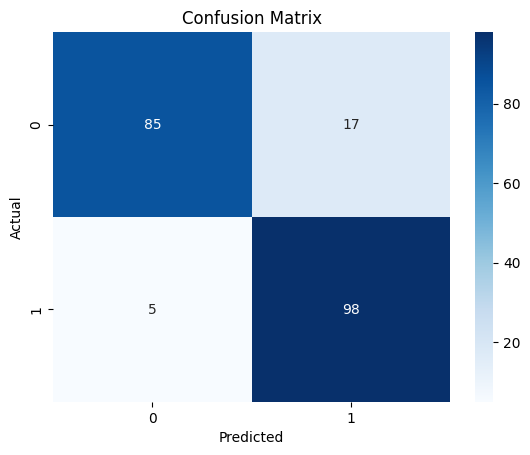

In [68]:
cm = confusion_matrix(ytest,pred)
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [69]:
new_data = np.array([[59,1,1,140,221,0,1,164,1,0.0,2,0,2]])
new_scaled = scaler.fit_transform(new_data)
new_pred = ml.predict(new_scaled)

if new_pred==0:
    print('Disease')
else:
    print('No disease')

Disease


In [73]:
row = 1024
row_data = x.iloc[row].values.reshape(1,-1)
row_scaled = scaler.fit_transform(row_data)
row_pred = ml.predict(row_scaled)
row_actual = y.iloc[row]

print(f'Row {row} : Model prediction - ','Disease' if row_pred[0]==0 else 'No disease')
print(f'Row {row} : Actual prediction - ','Disease' if row_actual==0 else 'No disease')

Row 1024 : Model prediction -  Disease
Row 1024 : Actual prediction -  Disease


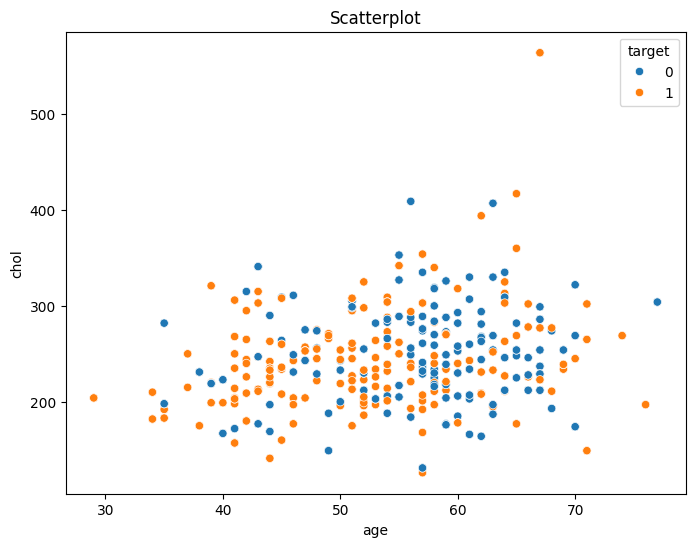

In [76]:
plt.figure(figsize=(8,6))
sn.scatterplot(x='age', y='chol', hue='target', data=data)
plt.title('Scatterplot')
plt.show()